In [1]:
from vibes.inference.bootstrap import pca_bootstrap, compute_lod
from pathlib import Path
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
REPO_ROOT = Path.cwd().resolve().parent
SPECTRA_DIR = REPO_ROOT / "data" / "pfte" / "laboratory"
CORRECTIONS_DIR = SPECTRA_DIR / "vibes" 

In [3]:
with open(CORRECTIONS_DIR  / "PB_c_loo_tau_elbo.pkl", "rb") as f:
    corrections_dict = pickle.load(f)

In [52]:
Z = np.array(pd.read_parquet(SPECTRA_DIR / "blanks.parquet"))
Y = pd.read_parquet(SPECTRA_DIR / "spectra.parquet")

In [20]:
i = 150

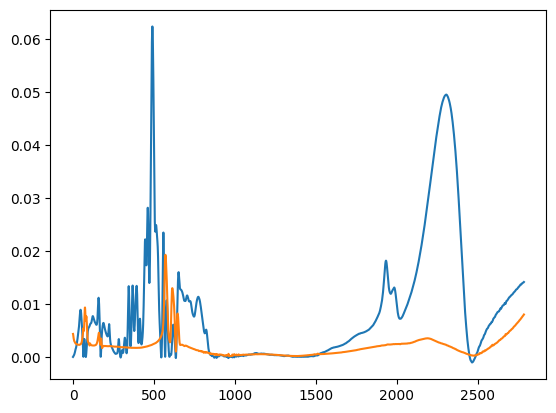

In [21]:
dct = corrections_dict[i]
plt.plot(dct["absorbance"])
plt.plot(dct["boot_lod"])

In [ ]:
dct = corrections_dict[0]
y = Y.loc[dct["sample_id"]].values
boot_x, boot_z = pca_bootstrap(y, Z, dct["tau"], dct["sigma"], dct["c"], B=100, loss="PB", verbose=False)
xi, stdev = compute_lod(boot_z, z, alpha=0.01)

dct["boot_x"] = boot_x
dct["boot_z"] = boot_z
dct["boot_stdev"] = stdev 
dct["boot_xi"] = xi 
dct["boot_lod"] = xi*stdev
dct["lod_alpha"] = 0.01 


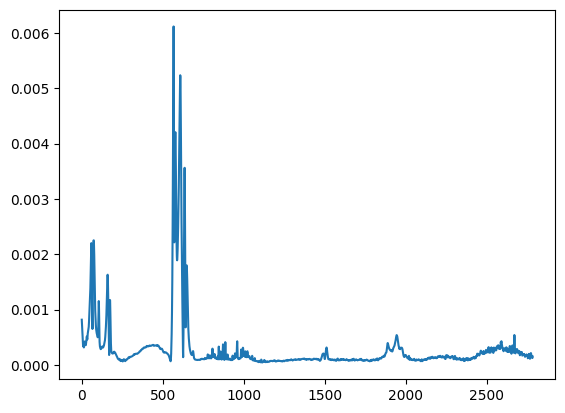

In [44]:
plt.plot(corrections_dict[0]["boot_lod"])

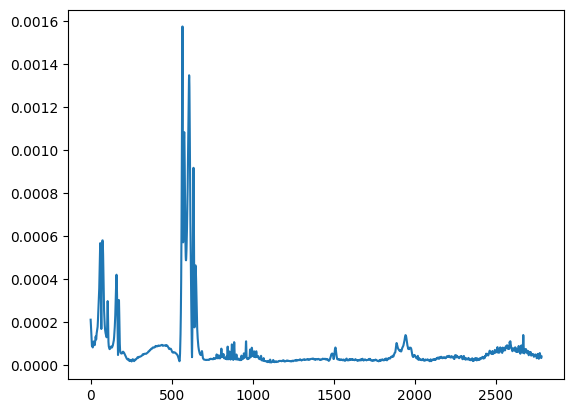

In [34]:
plt.plot(dct["boot_stdev"])

In [36]:
dct["boot_xi"]

np.float64(3.8857360381734343)

In [14]:
z = y - dct["absorbance"]

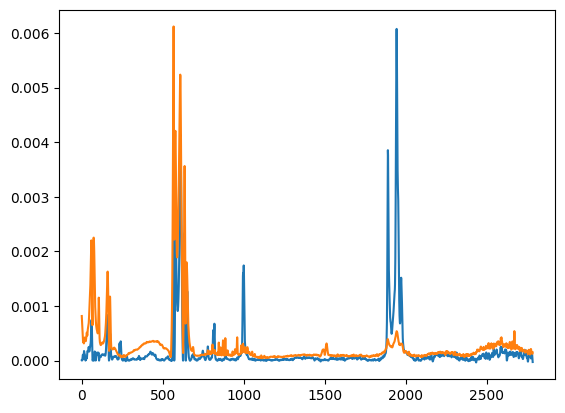

In [28]:
plt.plot(y-z)
plt.plot(xi*stdev)


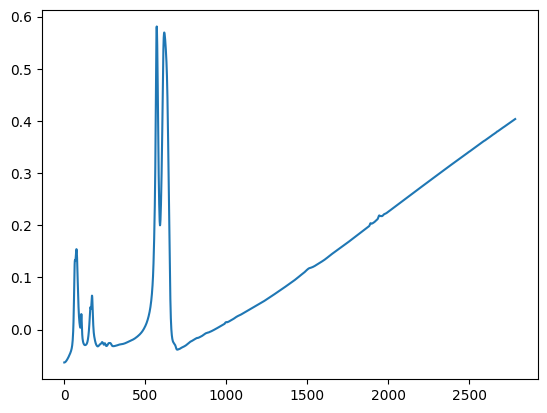

In [20]:
plt.plot(y)

In [13]:
for nn in dct:
    print(nn)

sample_id
absorbance
time
sigma
tau
c
x
d
nu
elbos_grid
elbo
mit
analyte
load
ref_corr


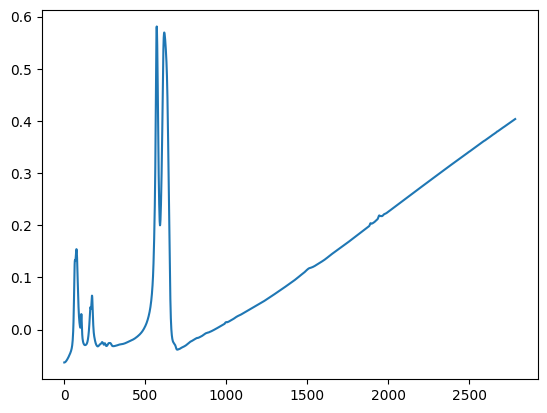

In [37]:
plt.plot(y)

{'sample_id': '01324.dpt',
 'absorbance': array([ 5.35800010e-06,  1.55205432e-11,  4.52158335e-06, ...,
         6.33269358e-05,  1.64010969e-05, -2.68951953e-05], shape=(2785,)),
 'time': 21.975189924240112,
 'sigma': np.float64(6.611994777883155e-06),
 'tau': np.float64(0.026753448586390602),
 'c': np.int64(47),
 'x': array([-1.17107057, -2.09866462, -0.14289192, -3.37542942,  1.62750027,
         0.37696475,  0.86563769, -4.545209  ,  9.56431389, -3.63597518,
        -0.27132406,  0.46925539,  1.39225884, -2.01423668, -1.9816935 ,
        -4.88413173,  2.67957555,  0.11675396,  4.38922315, -8.31604208,
        -0.0717608 ,  3.12937012,  5.42973624,  2.90664022,  4.4000644 ,
        -9.96785536, -1.91587451, -4.67116039, -5.81119966, -3.89016982,
        -0.4850391 , -4.23870122, -2.86731588,  4.76858093,  1.8892747 ,
        -4.33924133, -0.43844608, -1.80091165,  3.66441288,  2.40161937,
         1.66899021,  0.97102056,  0.09877549, -0.11464808, -0.06513855,
        -3.65017479, 

In [ ]:

PREPROC_DIR = REPO_ROOT / "data" / "preprocessed" / "teflon"

GT_DIR = REPO_ROOT / "data" / "spectrabase" / "teflon"
LAB_DIR = REPO_ROOT / "data" / "raw" / "teflon" / "laboratory_samples"
PREPROC_DIR = REPO_ROOT / "data" / "preprocessed" / "teflon"



    
with open(PREPROC_DIR / "blanks_dict.pkl", "rb") as f:
    blanks_dict = pickle.load(f)
    
with open(CORRECTIONS_DIR / "sigma_tau.pkl", "rb") as f:
    veb_pb_dict = pickle.load(f)
    
blanks_id = blanks_dict["2011"].copy().index.tolist()
Z = np.array(blanks_dict["2011"])   
chat_cv = loo_pca(Z)[1]
mu, _, _, W = pca(Z)
W = W[:,:chat_cv]

wn = np.sort(pd.read_csv(LAB_DIR / "zerofilling.txt", header=None).iloc[:, 0])

FileNotFoundError: [Errno 2] No such file or directory: '/home/fkamper/projects/pyvibes/data/preprocessed/teflon/raw_spectra_dict.pkl'

In [19]:
boot_dict = {}
for comp in ["12-Tricosanone","Ammonium sulfate","Suberic Acid","levoglucosan"]:
    boot_dict[comp] = veb_pb_dict[comp]

In [ ]:
alpha = 0.01
for comp in boot_dict.keys():
    for correction in boot_dict[comp]:
        sample_id,tau,sigma = correction["sample_id"], correction["tau"], correction["sigma_hat"]
        y = np.array(raw_spectra_dict[comp]["raw"].loc[sample_id])
        boot_x, boot_a, LOD = pca_bootstrap(y, Z, tau, sigma, c = chat_cv, B=100, loss = "PB",verbose=False)
        
        correction["boot_x"] = boot_x
        correction["boot_a"] = boot_a
        
        r = correction["absorbance"] - boot_a
        stdev = np.std(boot_a, axis=0)
        crit = np.quantile(np.max(r/stdev,axis=0), 1-alpha)
        
        correction["LOD"] = crit*stdev

KeyboardInterrupt: 

In [172]:
with open("boot_dict.pkl", "wb") as f:
    pickle.dump(boot_dict, f)

In [ ]:
for comp in boot_dict.keys():
    for correction in boot_dict[comp]:
        boot_a = correction["boot_a"]
        a = correction["absorbance"]
        
        r = correction["absorbance"] - boot_a
        stdev = np.std(boot_a, axis=0)
        crit = np.quantile(np.max(r/stdev,axis=0), 0.99)
        
        correction["LOD"] = crit*stdev

In [173]:
with open("boot_dict.pkl", "rb") as f:
    boot_dict = pickle.load(f)

In [174]:
comp = "levoglucosan"

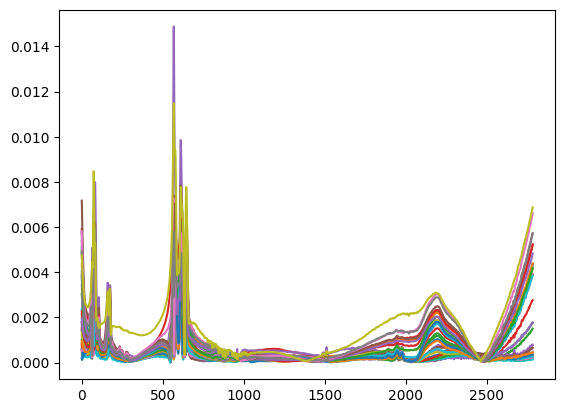

In [175]:
LOD = []
for correction in boot_dict[comp]:
    plt.plot(correction["LOD"])
    LOD.append(correction["LOD"])